# XGBoost

In the decision trees notebook, we saw how **gradient boosting** works: train a sequence of shallow trees, where each new tree fits the **residuals** (errors) left by all the previous trees combined. Each tree nudges the ensemble a little closer to the right answer, and the final prediction is a weighted sum of every tree in the sequence. Sklearn's `GradientBoostingClassifier` implements this cleanly.

**XGBoost** (eXtreme Gradient Boosting) is a production-grade implementation of the same idea — but with several important additions that make it faster, more regularized, and often more accurate. It has been the dominant algorithm on tabular data competitions for years, and understanding what it adds over vanilla gradient boosting is worth the time.

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
!pip install xgboost


[notice] A new release of pip available: 22.2.2 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier

## What XGBoost Adds

Sklearn's gradient booster is a faithful implementation of the classic algorithm. XGBoost makes five meaningful improvements:

### 1. Regularization built into the objective

Ordinary gradient boosting just minimizes prediction error. XGBoost adds **L1 and L2 penalty terms** directly into the loss function that the split-finding algorithm optimizes. This means the tree-building step itself is penalized for complexity — not as an afterthought, but as part of the math that decides where to split.

- `reg_alpha`: L1 penalty on leaf weights (drives small weights to exactly zero — sparsity)
- `reg_lambda`: L2 penalty on leaf weights (shrinks all weights smoothly — default is 1.0)

### 2. Second-order gradient information

Sklearn's boosting uses only the **first derivative** of the loss function (the gradient) to compute residuals. XGBoost uses both the first derivative and the **second derivative** (the Hessian). This is analogous to Newton's method in optimization: the second derivative tells you about the curvature of the loss surface, which gives you a more accurate step direction. In practice this means XGBoost converges in fewer trees for the same accuracy.

### 3. `gamma` — minimum loss reduction for a split

Before XGBoost will make a split, the split must reduce the regularized loss by at least `gamma`. If the best possible split doesn't clear that threshold, the node becomes a leaf instead. This is **built-in pruning**: the tree stops growing when additional splits aren't worth it. Increasing `gamma` produces simpler, more conservative trees.

### 4. Stochastic subsampling

- `subsample`: the fraction of training rows to sample (without replacement) before building each tree. Values less than 1.0 introduce randomness similar to random forests, reducing variance.
- `colsample_bytree`: the fraction of features to consider for each tree. Again, restricting this decorrelates the trees and often improves generalization.

### 5. Native missing value handling

When a feature value is missing for a training example, sklearn trees have to impute or drop it before fitting. XGBoost learns a **default branch direction** for each split during training — missing values are routed whichever way reduces loss the most. No preprocessing required.

### 6. Parallel tree construction

Sklearn's gradient booster builds each tree **node by node** in a serial loop. XGBoost finds the best split for **all nodes at the same depth in parallel**, using a pre-sorted block structure. This is why XGBoost trains dramatically faster on large datasets.

## Key Hyperparameters

| Parameter | What it controls | Typical range |
|---|---|---|
| `n_estimators` | Number of trees (boosting rounds) | 100–1000 |
| `learning_rate` | Shrinkage factor applied to each tree's contribution | 0.01–0.3 |
| `max_depth` | Maximum depth of each tree | 3–10 |
| `subsample` | Fraction of rows sampled per tree | 0.5–1.0 |
| `colsample_bytree` | Fraction of features sampled per tree | 0.5–1.0 |
| `reg_alpha` | L1 regularization on leaf weights | 0–10 |
| `reg_lambda` | L2 regularization on leaf weights (default: 1) | 0–10 |
| `gamma` | Minimum loss reduction required to make a split | 0–5 |

The `learning_rate` and `n_estimators` parameters interact strongly: a smaller learning rate generally needs more trees to reach the same training loss, but often generalizes better. The widget below lets you explore this tradeoff directly.

## Demo: Breast Cancer Dataset

We'll use the breast cancer dataset from sklearn — 569 tumor samples with 30 numerical features (radius, texture, perimeter, etc.) and a binary label: malignant (1) or benign (0). The task is to classify each tumor correctly.

We split 80/20 into train and test, fit both an XGBClassifier and sklearn's GradientBoostingClassifier with matched settings, and compare their accuracy.

In [4]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(f"Dataset shape: {X.shape}")
print(f"Class counts — malignant: {(y == 1).sum()}, benign: {(y == 0).sum()}")

Dataset shape: (569, 30)
Class counts — malignant: 357, benign: 212


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
# XGBoost
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    gamma=0.0,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train, y_train)

xgb_train_acc = accuracy_score(y_train, xgb.predict(X_train))
xgb_test_acc  = accuracy_score(y_test,  xgb.predict(X_test))

print(f"XGBoost         — Train: {xgb_train_acc:.4f}  Test: {xgb_test_acc:.4f}")

/Users/chelseatroy/.pyenv/versions/3.10.8/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [17:05:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

XGBoost         — Train: 1.0000  Test: 0.9561


In [7]:
# Sklearn GradientBoostingClassifier (matched settings where possible)
gbc = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    random_state=42
)
gbc.fit(X_train, y_train)

gbc_train_acc = accuracy_score(y_train, gbc.predict(X_train))
gbc_test_acc  = accuracy_score(y_test,  gbc.predict(X_test))

print(f"sklearn GBC     — Train: {gbc_train_acc:.4f}  Test: {gbc_test_acc:.4f}")

GradientBoostingClassifier(max_depth=4, random_state=42, subsample=0.8)

sklearn GBC     — Train: 1.0000  Test: 0.9561


(0.88, 1.01)

Text(0, 0.5, 'Accuracy')

Text(0.5, 1.0, 'XGBoost vs sklearn GradientBoostingClassifier')

Text(0.0, 1.001, '1.0000')

Text(1.0, 0.957140350877193, '0.9561')

Text(2.0, 1.001, '1.0000')

Text(3.0, 0.957140350877193, '0.9561')

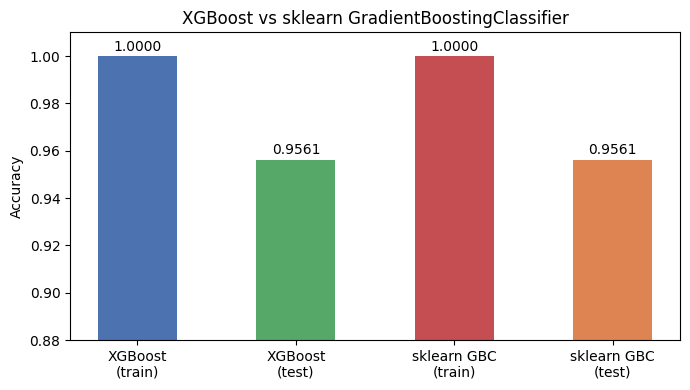

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))

models   = ['XGBoost\n(train)', 'XGBoost\n(test)', 'sklearn GBC\n(train)', 'sklearn GBC\n(test)']
scores   = [xgb_train_acc, xgb_test_acc, gbc_train_acc, gbc_test_acc]
colors   = ['#4c72b0', '#55a868', '#c44e52', '#dd8452']

bars = ax.bar(models, scores, color=colors, width=0.5)
ax.set_ylim(0.88, 1.01)
ax.set_ylabel('Accuracy')
ax.set_title('XGBoost vs sklearn GradientBoostingClassifier')

for bar, score in zip(bars, scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f'{score:.4f}',
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

## Interactive Widget: Learning Rate vs. Number of Estimators

The `learning_rate` controls how much each new tree contributes to the ensemble. A high learning rate means each tree has a large influence — the model converges quickly but can overshoot and overfit. A low learning rate means each tree contributes a tiny amount, which requires more trees to reach the same training loss but often gives better generalization.

Use the sliders below to explore this tradeoff. Notice:
- With a high learning rate and many estimators, training accuracy climbs but test accuracy may plateau or drop
- With a low learning rate, you often need more estimators before the model converges — but the train/test gap tends to stay narrower
- The green bar (test accuracy) is what matters for real-world performance

In [9]:
def fit_xgb_interactive(learning_rate, n_estimators):
    model = XGBClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    gap       = train_acc - test_acc

    print(f"learning_rate={learning_rate:.2f}  n_estimators={n_estimators}")
    print(f"Train accuracy: {train_acc:.4f}")
    print(f"Test accuracy:  {test_acc:.4f}")
    if gap > 0.05:
        print(f"(Gap of {gap:.4f} — possible overfitting)")
    else:
        print(f"(Gap of {gap:.4f} — model is generalizing well)")

    fig, ax = plt.subplots(figsize=(5, 3.5))
    bars = ax.bar(
        ['Train accuracy', 'Test accuracy'],
        [train_acc, test_acc],
        color=['#4c72b0', '#55a868'],
        width=0.4
    )
    ax.set_ylim(0.88, 1.01)
    ax.set_ylabel('Accuracy')
    ax.set_title(f'XGBoost  lr={learning_rate:.2f}  trees={n_estimators}')
    for bar, score in zip(bars, [train_acc, test_acc]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f'{score:.4f}',
            ha='center', va='bottom', fontsize=11
        )
    plt.tight_layout()
    plt.show()

widgets.interact(
    fit_xgb_interactive,
    learning_rate=widgets.FloatSlider(
        value=0.1, min=0.01, max=1.0, step=0.01,
        description='LR:', style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    ),
    n_estimators=widgets.IntSlider(
        value=100, min=10, max=300, step=10,
        description='Trees:', style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    )
);

interactive(children=(FloatSlider(value=0.1, description='LR:', layout=Layout(width='400px'), max=1.0, min=0.0…

## Feature Importance

Like sklearn's gradient booster, XGBoost provides feature importance scores. The default (`weight`) counts how many times each feature was used in a split across all trees. Two other options are `gain` (average loss reduction from splits using this feature) and `cover` (average number of training examples affected by splits on this feature).

`gain` is usually the most informative: a feature used in only a few splits but producing large loss reductions may be more valuable than one used in many shallow, low-impact splits.

<Axes: >

Text(0.5, 0, 'Average gain per split')

Text(0.5, 1.0, 'XGBoost Feature Importance (gain) — Top 15 Features')

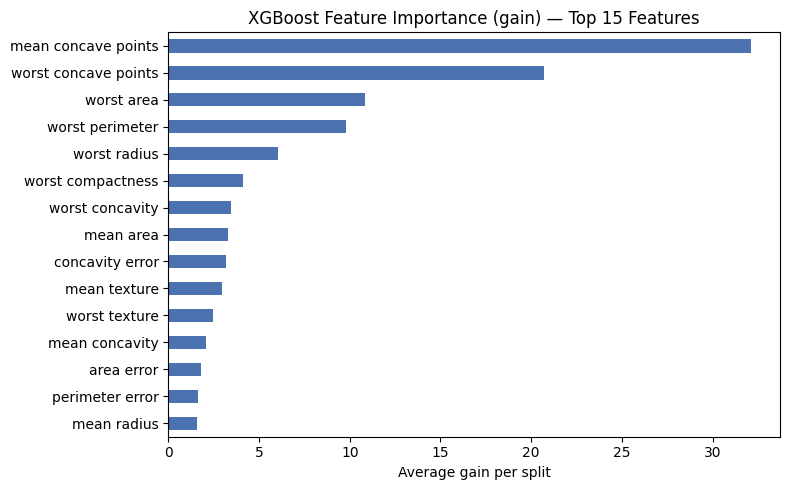

In [10]:
importance_gain = pd.Series(
    xgb.get_booster().get_score(importance_type='gain'),
    name='gain'
).sort_values(ascending=True)

# Keep the top 15 features for readability
top15 = importance_gain.tail(15)

fig, ax = plt.subplots(figsize=(8, 5))
top15.plot(kind='barh', color='#4c72b0', ax=ax)
ax.set_xlabel('Average gain per split')
ax.set_title('XGBoost Feature Importance (gain) — Top 15 Features')
plt.tight_layout()
plt.show()

## Summary

XGBoost is gradient boosting with five concrete improvements:

1. **Regularization in the objective** (`reg_alpha`, `reg_lambda`) — the split-finding math itself penalizes complexity, not just post-hoc pruning
2. **Second-order gradients** — uses curvature information (the Hessian) for more accurate steps, converging in fewer trees
3. **`gamma`** — a minimum-loss-reduction threshold before any split is made, acting as automatic pruning
4. **Stochastic subsampling** (`subsample`, `colsample_bytree`) — decorrelates trees for lower variance, same idea as random forests
5. **Parallel tree construction** — dramatically faster training on large datasets

The cost of all this flexibility is a larger hyperparameter space. In practice, a good starting point is: `learning_rate=0.1`, `n_estimators=100–300`, `max_depth=4–6`, `subsample=0.8`, `colsample_bytree=0.8`, `reg_lambda=1.0`. Use cross-validation or early stopping on a validation set to tune from there.